## Communication analysis and visualization

### Import libraries and define functions

In [1]:
# Import required libraries
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from skimage import filters
import seaborn as sns
import ptitprince as pt
from pandas import DataFrame, Series
from math import *

def load_prepared(load_path):
    """Load a prepared data dictionary from a pickle file."""
    with open(load_path, 'rb') as f:
        prepared_dict = pickle.load(f)
    return prepared_dict

def remove_outliers(group, series_name, lower_quantile, upper_quantile):
    """Remove rows outside the specified quantile range for a given column."""
    series = group[series_name]
    mask = pd.Series(True, index=group.index)
    if lower_quantile is not None:
        mask &= series >= series.quantile(lower_quantile)
    if upper_quantile is not None:
        mask &= series <= series.quantile(upper_quantile)
    return group[mask]

def apply_remove_outliers_by_group(df, group_cols, series_name, lower_quantile, upper_quantile):
    """Apply quantile-based filtering separately to each group."""
    chunks = []
    for _, g in df.groupby(group_cols):
        chunks.append(remove_outliers(g, series_name=series_name, lower_quantile=lower_quantile, upper_quantile=upper_quantile))
    if len(chunks) == 0:
        return df.iloc[0:0].copy()
    return pd.concat(chunks, ignore_index=True)

def add_normalized_column(droplet_groups, reference_droplet, value_column, normalized_column, group_column, normalize_method,):
    """Normalize fluorescence intensities to reference droplets within each group."""
    reference_df = None
    for df in droplet_groups:
        if len(df) > 0 and df['Droplet'].iloc[0] == reference_droplet:
            reference_df = df
            break
    if reference_df is None:
        raise ValueError(f"Reference droplet '{reference_droplet}' not found")
    if group_column not in reference_df.columns:
        raise ValueError(f"group_column '{group_column}' not found in reference dataframe")

    group_refs = {}
    for group_value in reference_df[group_column].dropna().unique():
        vals = reference_df[reference_df[group_column] == group_value][value_column]
        if len(vals) == 0:
            continue
        if normalize_method == 'mean':
            group_refs[group_value] = np.mean(vals)
        elif normalize_method == 'median':
            group_refs[group_value] = np.median(vals)
        else:
            raise ValueError("normalize_method must be 'mean' or 'median'")

    normalized_groups = []
    for df in droplet_groups:
        df_copy = df.copy()
        df_copy.loc[:, normalized_column] = np.nan
        for group_value, ref_value in group_refs.items():
            mask = df_copy[group_column] == group_value
            if ref_value == 0 or np.isnan(ref_value):
                df_copy.loc[mask, normalized_column] = np.nan
            else:
                df_copy.loc[mask, normalized_column] = df_copy.loc[mask, value_column] / ref_value
        normalized_groups.append(df_copy)
    return normalized_groups

def add_adjacent_group(df):
    """Classify droplets as adjacent ('o') or non-adjacent ('x')."""
    out = df.copy()
    out['adjacent_group'] = np.where(out['adjacent_outline'].astype(str).str.startswith('o'), 'o', 'x')
    return out

def build_series_dict_from_base(dN_Rep_base, d_Rep_base, dN_NDK_base, d_NDK_base):
    """Generate full, adjacent, and non-adjacent droplet groups from base datasets."""
    return {
        'N_Rep': dN_Rep_base,
        'Rep': d_Rep_base,
        'N_NDK': dN_NDK_base,
        'NDK': d_NDK_base,
        'Rep_o': d_Rep_base[d_Rep_base['adjacent_group'] == 'o'].copy(),
        'Rep_x': d_Rep_base[d_Rep_base['adjacent_group'] == 'x'].copy(),
        'N_Rep_o': dN_Rep_base[dN_Rep_base['adjacent_group'] == 'o'].copy(),
        'N_Rep_x': dN_Rep_base[dN_Rep_base['adjacent_group'] == 'x'].copy(),
        'NDK_o': d_NDK_base[d_NDK_base['adjacent_group'] == 'o'].copy(),
        'NDK_x': d_NDK_base[d_NDK_base['adjacent_group'] == 'x'].copy(),
        'N_NDK_o': dN_NDK_base[dN_NDK_base['adjacent_group'] == 'o'].copy(),
        'N_NDK_x': dN_NDK_base[dN_NDK_base['adjacent_group'] == 'x'].copy(),
    }

def arrange_axis(ax=None):
    """Apply common axis formatting to a matplotlib axis."""
    if ax is None:
        ax = plt.gca()
    sns.set_style('ticks')
    ax.grid(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

### Data loading

In [3]:
# Each file contains all necessary information for individual droplets.
data_dir = os.path.join(os.path.curdir, "Processed data") # Full dataset

# prepared_dex_raw (Fig. 3)
# 'CB_Fl_Int': Cascade Blue-DEX fluorescence intensity.
# 'Red_LUV' and 'Blue_LUV': fluorescence intensities of liposomes labeled with ATTO 565 ('Red') and ATTO 647 ('Blue'), respectively.
# 'FI_Int-Out_Back': corrected FITC fluorescence intensity.
# 'Droplet': droplets 1 ('Red') or 2 ('Blue').
# 'adjacent_outline': whether the droplet is adjacent to the other droplet type ('o') or not ('x').
# 'DEX': average molecular weight of FITC-labeled DEX.'150k_BSA01' indicates experiments performed with reduced BSA.
with open(os.path.join(data_dir, "260710 prepared_data_dex.pkl"), "rb") as f:
    prepared_dex_raw = pickle.load(f)

# prepared_fam_rna_raw (Fig. S14)
# Essentially the same as above.
# 'FI_Int-Out_Back': corrected FAM fluorescence intensity.
# 'FAM-RNA': FAM-labeled RNA 1 ('#56_BSA01') or RNA 2 ('ZN1_BSA01').
with open(os.path.join(data_dir, "260710 prepared_data_fam_rna.pkl"), "rb") as f:
    prepared_fam_rna_raw = pickle.load(f)

# prepared_comm_raw (Figs. 4, 5, S12, and S15)
# 'CB_Fl_Int': Cascade Blue-DEX fluorescence intensity.
# 'Red_LUV': fluorescence intensity of liposomes labeled with ATTO 565.
# 'FI_Int-Out_Back': corrected molecular beacon (MB) fluorescence intensity.
# 'Droplet': droplets 1 ('Green') or 2 ('NoGreen').
# 'adjacent_outline': whether the droplet is adjacent to the other droplet type ('o') or not ('x').
with open(os.path.join(data_dir, "260710 prepared_data_comm.pkl"), "rb") as f:
    prepared_comm_raw = pickle.load(f)

<div style="margin-top:16px; font-size:16px;">
  <b style="font-size:20px;">Fig. 3.</b> DEX exchange between stabilized, colony-forming ATPS droplets.
</div>

In [5]:
prepared_dex = prepared_dex_raw.copy() # Data

# Identify droplets 1 and 2. 'Red' and 'Blue' correspond to ATTO 565 and ATTO 647, respectively.
dex_labels = ['10k', '150k', '150k_BSA01', '2000k']
for dex_label in dex_labels:
    key_red, key_blue = f'd_{dex_label}_red', f'd_{dex_label}_blue'
    d_red, d_blue = prepared_dex[key_red].copy(), prepared_dex[key_blue].copy() 
    branch_suffix_red = d_red["Filename"].str.extract(r"\d+(-\d+)", expand=False).fillna("") # for dividing two experiments performed on 241024
    branch_suffix_blue = d_blue["Filename"].str.extract(r"\d+(-\d+)", expand=False).fillna("") 
    d_red.loc[:, "Date"] = d_red["Date"] + branch_suffix_red
    d_blue.loc[:, "Date"] = d_blue["Date"] + branch_suffix_blue
    
    # Exclude objects with mean liposome fluorescence intensity ≥95% of the maximum possible pixel intensity,
    # which indicates substantial liposome aggregation.
    LUV_threshold = 4095*0.95
    d_red = d_red.loc[d_red['Red_LUV'] < LUV_threshold, :].copy()
    d_blue = d_blue.loc[d_blue['Blue_LUV'] < LUV_threshold, :].copy()
    d_red = d_red.loc[d_red['Blue_LUV'] < LUV_threshold, :].copy() 
    d_blue = d_blue.loc[d_blue['Red_LUV'] < LUV_threshold, :].copy()
    
    # Retain only the top 75% of droplets ranked by Cascade Blue fluorescence intensity to reduce variation among imaging fields and within images.
    d_red = apply_remove_outliers_by_group(d_red, group_cols=['Date', 'Sample_Number'],\
            series_name='CB_Fl_Int', lower_quantile=0.25, upper_quantile=None)
    d_blue = apply_remove_outliers_by_group(d_blue, group_cols=['Date', 'Sample_Number'],\
        series_name='CB_Fl_Int', lower_quantile=0.25, upper_quantile=None)
    
    # For each image, corrected FITC-DEX fluorescence intensities in droplets 2 were normalized to 
    # the corresponding mean fluorescence intensity in droplets 1. 
    d_red, d_blue = add_normalized_column([d_red, d_blue], reference_droplet='Red', value_column='Fl_Int-Out-Back', \
                    normalized_column='Normalized_(Fl_Int-Out-Back)', group_column='Filename', normalize_method='mean')
    
    # Remove rows with NaNs in the normalized fluorescence intensity column, which can occur 
    # when the reference droplets used for normalization are removed by Cascade Blue filtering.
    prepared_dex[key_red], prepared_dex[key_blue] = d_red.dropna(subset=['Normalized_(Fl_Int-Out-Back)']), d_blue.dropna(subset=['Normalized_(Fl_Int-Out-Back)'])

# Update droplet_groups
ordered_keys = ['d_10k_blue', 'd_10k_red', 'd_150k_blue', 'd_150k_red', 'd_150k_BSA01_blue', 'd_150k_BSA01_red','d_2000k_blue', 'd_2000k_red']
prepared_dex['droplet_groups'] = [prepared_dex[k] for k in ordered_keys if k in prepared_dex]

# Combine
dex_comm = pd.concat([prepared_dex[k] for k in ordered_keys], ignore_index=True)
dex_comm['adjacent_outline'] = dex_comm['adjacent_outline'].str.split(',').str[0]
dex_comm.loc[dex_comm['Normalized_(Fl_Int-Out-Back)'] < 0, 'Normalized_(Fl_Int-Out-Back)'] = 0
dex_comm_blue, dex_comm_red = dex_comm[dex_comm['Droplet'] == 'Blue'], dex_comm[dex_comm['Droplet'] == 'Red']

# Adjacency (150k DEX, 0.1 BSA)
plot_dex_adj = dex_comm_blue[dex_comm_blue['DEX'].isin(['150k_BSA01'])].copy()
plot_dex_adj['DEX'] = plot_dex_adj['DEX'] + '_' + plot_dex_adj['adjacent_outline'].str.split(',').str[0]
plot_dex_comm = pd.concat([dex_comm_blue, plot_dex_adj], ignore_index=True)

# Check the maximum normalized fluorescence intensity.
# print('ymax',plot_dex_comm['Normalized_(Fl_Int-Out-Back)'].max())

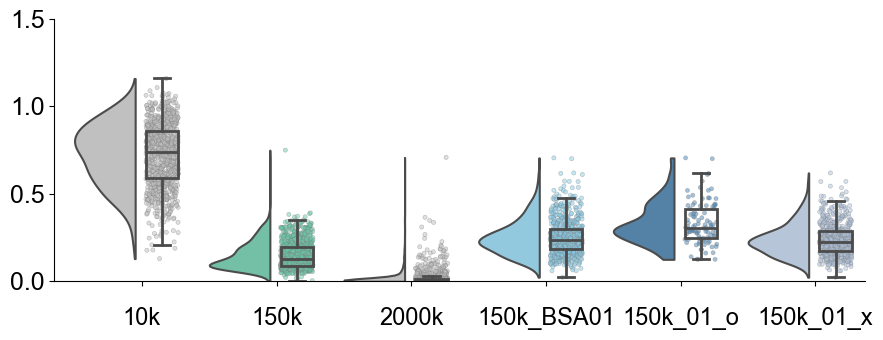

DEX
10k              995
150k            1030
2000k           1172
150k_BSA01       682
150k_BSA01_o      98
150k_BSA01_x     584
dtype: int64


In [6]:
# Visualization: RainCloud plot
palette = {'10k': 'silver', '150k': 'mediumaquamarine', '2000k': 'silver', \
           '150k_BSA01': 'skyblue','150k_BSA01_o': 'steelblue','150k_BSA01_x': 'lightsteelblue'}
series_list = ['10k', '150k', '2000k','150k_BSA01','150k_BSA01_o','150k_BSA01_x']

fig, ax = plt.subplots(1, 1, figsize=(9,3.5))
y_max = plot_dex_comm['Normalized_(Fl_Int-Out-Back)'].max()
pt.RainCloud(data=plot_dex_comm, x='DEX', y='Normalized_(Fl_Int-Out-Back)', order=series_list, palette=palette,\
             width_viol=0.9, linewidth= 1.5, bw=0.3, scale='width', box_showfliers=False,width_box=0.24, box_linewidth=2,\
             point_size=3, rain_linewidth=0.4, rain_alpha=0.5, rain_edgecolor='grey', jitter=0.12 ,ax=ax)

for line in ax.lines:
    line.set_linewidth(2)
arrange_axis(ax)

ax.tick_params(axis ='x',labelsize =17), ax.tick_params(axis ='y',labelsize =18)
ax.set_xlabel(''), ax.set_ylabel('')
ax.tick_params(axis='x', pad=15)
offset = -0.15
ax.set_xticks(np.arange(len(series_list)) + offset)
ax.set_xticklabels(['10k', '150k', '2000k','150k_BSA01','150k_01_o','150k_01_x'])
ax.set_xlim(-0.8, None), ax.set_ylim(0,1.5)

plt.tight_layout()
plt.show()

# Number of plotted droplets
print(plot_dex_comm.groupby(['DEX']).size().reindex(series_list))

150k & 150k_BSA01: p= 0.03617694292244143
150k_BSA01_o & 150k_BSA01_x: p= 0.0046159226878781994


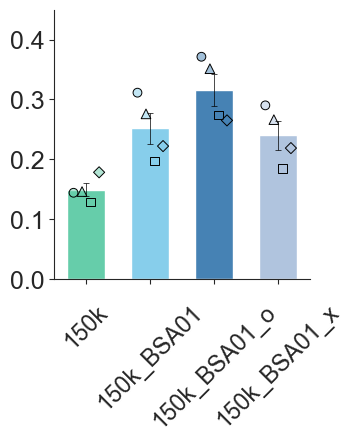

In [7]:
# Visualization: Bar plot
# In the DEX labels, 'o' and 'x' indicate adjacent and non-adjacent droplets, respectively.
series = ['150k', '150k_BSA01', '150k_BSA01_o', '150k_BSA01_x']
dates = ['260409','260413','260415','260609']
summary_table = plot_dex_comm.groupby(['DEX', 'Date'])['Normalized_(Fl_Int-Out-Back)'].mean().unstack()
d = summary_table.loc[series]
raws = np.array(d[dates])
aves = np.average(raws,axis = 1)
ses = np.std(raws, ddof=1, axis=1)/sqrt(len(raws[0]))

cs = [palette[s] for s in series]
facecolors = [mcolors.to_rgba(c, alpha=0.5) for c in cs]
x_position = np.arange(len(series))
error_bar_set = dict(lw = 0.5, capthick = 0.5, capsize = 2)
width = 0.6

fig, ax = plt.subplots(1, 1, figsize=(3.3,3.5))
ax.bar(x_position, aves, width=width, yerr=ses, error_kw=error_bar_set, color = cs)
ax.set_xticks(x_position), ax.set_xticklabels(series)
plt.xticks(rotation=45)

ms = ['o','^','s','D','v']
ss = np.array([40,48,36,32,48])
L = 12/len(raws[0])
xs = np.linspace(-width/L, width/L, len(dates))
for i in range(len(dates)):
    raw = raws[:,i]
    x = x_position + xs[i]
    ax.scatter(x, raw, color=cs, marker=ms[i], s=ss[i], facecolor=facecolors, edgecolor='k', linewidth=0.7)

ax.tick_params(axis ='x',labelsize =17), ax.tick_params(axis ='y',labelsize =18)
ax.tick_params(axis='x', pad=12)
ax.set_xlim(-0.5, x_position[-1]+0.5)
ax.set_ylim(0,0.45)
arrange_axis(ax)

# Calculate p-values using paired t-tests across experimental dates.
for i in range(2):
    t_stat, p_value = stats.ttest_rel(raws[i*2,:], raws[i*2+1,:])
    print(series[i*2]+' & '+series[i*2+1]+': p=', p_value)

<div style="margin-top:16px; font-size:16px;">
  <b style="font-size:20px;">Fig. S14.</b> FAM-RNA exchange between stabilized ATPS droplets.
</div>

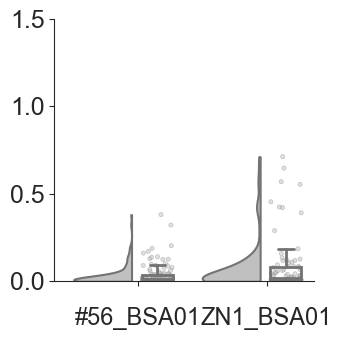

FAM-RNA
#56_BSA01    114
ZN1_BSA01     85
dtype: int64


In [9]:
# Apply essentially the same preprocessing as in Fig. 3.
# '#56' and 'ZN1' correspond to RNA 1 and RNA 2, respectively.
prepared_fam_rna = prepared_fam_rna_raw.copy()

rna_labels = ['#56_BSA01', 'ZN1_BSA01']
for rna_label in rna_labels:
    key_red, key_blue = f'd_{rna_label}_red', f'd_{rna_label}_blue'
    d_red, d_blue = prepared_fam_rna[key_red], prepared_fam_rna[key_blue]
    
    LUV_threshold = 4095*0.95
    d_red = d_red.loc[d_red['Red_LUV'] < LUV_threshold, :].copy()
    d_blue = d_blue.loc[d_blue['Blue_LUV'] < LUV_threshold, :].copy()
    d_red = d_red.loc[d_red['Blue_LUV'] < LUV_threshold, :].copy() 
    d_blue = d_blue.loc[d_blue['Red_LUV'] < LUV_threshold, :].copy()

    d_red = apply_remove_outliers_by_group(d_red, group_cols=['Date', 'Sample_Number'],\
            series_name='CB_Fl_Int', lower_quantile=0.25, upper_quantile=None)
    d_blue = apply_remove_outliers_by_group(d_blue, group_cols=['Date', 'Sample_Number'],\
        series_name='CB_Fl_Int', lower_quantile=0.25, upper_quantile=None)
    
    d_red, d_blue = add_normalized_column([d_red, d_blue], reference_droplet='Red', value_column='Fl_Int-Out-Back', \
                    normalized_column='Normalized_(Fl_Int-Out-Back)', group_column='Filename', normalize_method='mean')
    prepared_fam_rna[key_red], prepared_fam_rna[key_blue] = d_red, d_blue

ordered_keys = ['d_#56_BSA01_blue', 'd_#56_BSA01_red', 'd_ZN1_BSA01_blue', 'd_ZN1_BSA01_red']
prepared_fam_rna['droplet_groups'] = [prepared_fam_rna[k] for k in ordered_keys if k in prepared_fam_rna]

fam_rna_comm = pd.concat([prepared_fam_rna[k] for k in ordered_keys], ignore_index=True)
fam_rna_comm['adjacent_outline'] = fam_rna_comm['adjacent_outline'].str.split(',').str[0]
fam_rna_comm.loc[fam_rna_comm['Normalized_(Fl_Int-Out-Back)'] < 0, 'Normalized_(Fl_Int-Out-Back)'] = 0
fam_rna_comm_blue = fam_rna_comm[fam_rna_comm['Droplet'] == 'Blue'].copy()
fam_rna_comm_red = fam_rna_comm[fam_rna_comm['Droplet'] == 'Red'].copy()

# Visualization: RainCloud plot
palette = {'#56_BSA01':'silver', 'ZN1_BSA01':'silver'}
series_list = ['#56_BSA01', 'ZN1_BSA01']

fig, ax = plt.subplots(1, 1, figsize=(3.5,3.5))
y_max = fam_rna_comm_blue['Normalized_(Fl_Int-Out-Back)'].max()
pt.RainCloud(data=fam_rna_comm_blue, x='FAM-RNA', y='Normalized_(Fl_Int-Out-Back)', order=series_list, palette=palette,\
             width_viol=0.9, linewidth= 1.5, bw=0.3, scale='width', box_showfliers=False, width_box=0.24, box_linewidth=2,\
             point_size=3, rain_linewidth=0.4, rain_alpha=0.5, rain_edgecolor='grey', jitter=0.12 ,ax=ax)

for line in ax.lines:
    line.set_linewidth(2)
arrange_axis()

ax.tick_params(axis ='x',labelsize =17), ax.tick_params(axis ='y',labelsize =18)
ax.set_xlabel(''), ax.set_ylabel('')
ax.tick_params(axis='x', pad=15)
offset = -0.15 
ax.set_xticks(np.arange(len(series_list)) + offset)
ax.set_xticklabels(series_list)
ax.set_xlim(-0.8, None), ax.set_ylim(0,1.5)

plt.tight_layout()
plt.show()

# Number of plotted droplets
print(fam_rna_comm_blue.groupby(['FAM-RNA']).size())

<div style="margin-top:16px; font-size:16px;">
  <b style="font-size:20px;">Fig. 4.</b> Genomic RNA replication via inter-droplet diffusion of an encoded protein in stabilized ATPS droplet colonies.
</div>

<div style="font-size:16px;">
  <b style="font-size:20px;">Fig. 5.</b> Cooperative genomic RNA replication via bidirectional droplet–droplet molecular communication in stabilized ATPS droplet colonies.
</div>

<div style="font-size:16px;">
  <b style="font-size:20px;">Fig. S12.</b> Genomic RNA replication via inter-droplet communication of an encoded protein: analysis of droplets 1.
</div>

<div style="font-size:16px;">
  <b style="font-size:20px;">Fig. S15.</b> Cooperative genomic RNA replication via bidirectional droplet–droplet molecular communication: analysis of the other droplet populations.
</div>

In [11]:
prepared_comm = prepared_comm_raw.copy()

# Select the dataset to analyze:
# Type = 'Rep_comm', Droplet_Ser = 'NDK' for Fig. 4F/G
# Type = 'Rep_comm', Droplet_Ser = 'Rep' for Fig. S12
# Type = 'NTP_comm', Droplet_Ser = 'Rep' for Fig. 5D/E
# Type = 'NTP_comm', Droplet_Ser = 'NDK' for Fig. S15A/B
# Type = 'NTP_syn_Rep_comm', Droplet_Ser = 'NDK' for Fig. 5G/H
# Type = 'NTP_syn_Rep_comm', Droplet_Ser = 'Rep' for Fig. S15C/D

Type, Droplet_Ser = 'Rep_comm', 'NDK'

if Type == 'Rep_comm':
    selected = prepared_comm['Rep_comm']; normalized_reference_droplet = 'N_Rep'; print("Rep_comm")
elif Type == 'NTP_comm':
    selected = prepared_comm['NTP_comm']; normalized_reference_droplet = 'N_NDK'; print("NTP_comm")
elif Type == 'NTP_syn_Rep_comm':
    selected = prepared_comm['NTP_syn_Rep_comm']; normalized_reference_droplet = 'N_Rep'; print("NTP_syn_Rep_comm")

# Labels ending in '_o' and '_x' indicate adjacent and non-adjacent droplets, respectively.
# Labels beginning with 'N_' indicate negative control experiments.
if Droplet_Ser == 'NDK':
    series_list = ['NDK', 'N_NDK', 'NDK_o', 'N_NDK_o', 'NDK_x', 'N_NDK_x']
elif Droplet_Ser == 'Rep':
    series_list = ['Rep', 'N_Rep', 'Rep_o', 'N_Rep_o', 'Rep_x', 'N_Rep_x']

# Analysis
data = selected['data']
d_Rep, dN_Rep, d_NDK, dN_NDK = selected['d_Rep'].copy(), selected['dN_Rep'].copy(), selected['d_NDK'].copy(), selected['dN_NDK'].copy()

# Exclude objects with mean liposome fluorescence intensity ≥95% of the maximum possible pixel intensity,
# which indicates substantial liposome aggregation.
LUV_threshold = 4095*0.95
d_Rep = d_Rep.loc[d_Rep['Red_LUV'] < LUV_threshold, :].copy()
dN_Rep = dN_Rep.loc[dN_Rep['Red_LUV'] < LUV_threshold, :].copy()
d_NDK = d_NDK.loc[d_NDK['Red_LUV'] < LUV_threshold, :].copy()
dN_NDK = dN_NDK.loc[dN_NDK['Red_LUV'] < LUV_threshold, :].copy()

# Define the four original groups.
base_series = {'N_Rep': dN_Rep, 'Rep': d_Rep, 'N_NDK': dN_NDK, 'NDK': d_NDK}

# Retain only the top 75% of droplets ranked by Cascade Blue fluorescence intensity to reduce variation among imaging fields and within images.
outlier_group = ['Date', 'Sample_Number']
outlier_lower_q, outlier_upper_q = 0.25, None
for key in ['N_Rep', 'Rep', 'N_NDK', 'NDK']:
    base_series[key] = apply_remove_outliers_by_group(base_series[key], group_cols=outlier_group, series_name='CB_Fl_Int',\
                       lower_quantile=outlier_lower_q, upper_quantile=outlier_upper_q)

# To minimize potential misclassification near the cluster boundary, the 1% of droplets with the lowest intensities in droplets 1 
# and those with the highest intensities in droplets 2 were removed.
for key in ['N_Rep', 'Rep', 'N_NDK', 'NDK']:
    if key in['N_Rep', 'Rep']:
        outlier_lower_q, outlier_upper_q = 0.01, None
    elif key in ['N_NDK', 'NDK']:
        outlier_lower_q, outlier_upper_q = None, 0.99
    base_series[key] = apply_remove_outliers_by_group(base_series[key], outlier_group, 'FAM_Fl_Int', \
                     lower_quantile=outlier_lower_q, upper_quantile=outlier_upper_q)

# Normalize fluorescence intensities to the corresponding mean values in negative control experiments for each experimental date.
base_groups = [base_series['N_Rep'], base_series['Rep'], base_series['N_NDK'], base_series['NDK']]
base_groups = add_normalized_column(base_groups, reference_droplet=normalized_reference_droplet,\
    value_column='Fl_Int-Out', normalized_column='Normalized_Fl_Int-Out',group_column='Date', normalize_method='mean')
base_series['N_Rep'], base_series['Rep'], base_series['N_NDK'], base_series['NDK'] = base_groups

# Adjacency
dN_Rep, d_Rep = add_adjacent_group(base_series['N_Rep']), add_adjacent_group(base_series['Rep'])
dN_NDK, d_NDK = add_adjacent_group(base_series['N_NDK']), add_adjacent_group(base_series['NDK'])
series_dict = build_series_dict_from_base(dN_Rep, d_Rep, dN_NDK, d_NDK)

# DataFrame for plotting
chunks = []
for s in series_list:
    tmp = series_dict[s].copy()
    tmp.loc[:, 'SeriesLabel'] = s
    chunks.append(tmp)
plot_df = pd.concat(chunks, ignore_index=True)

# Check the maximum normalized fluorescence intensity.
# print('ymax',plot_df['Normalized_Fl_Int-Out'].max())

Rep_comm


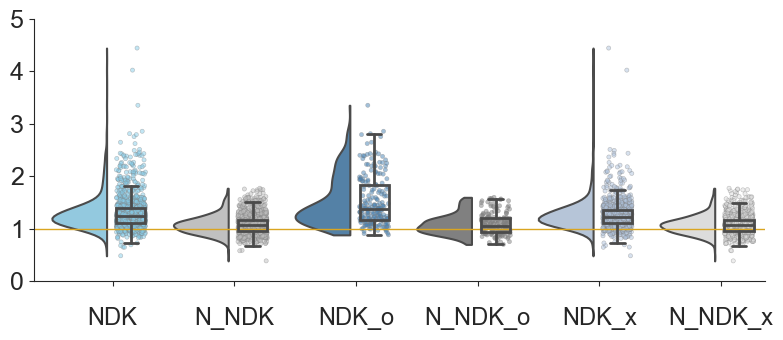

SeriesLabel
NDK        1286
N_NDK      1245
NDK_o       212
N_NDK_o     175
NDK_x      1074
N_NDK_x    1070
dtype: int64


In [12]:
# Visualization: RainCloud plot
palette = {'Rep': 'mediumaquamarine', 'Rep_o': 'seagreen','Rep_x': '#D2EEDF',
           'NDK': 'skyblue', 'NDK_o': 'steelblue', 'NDK_x': 'lightsteelblue', 
           'N_NDK': 'silver', 'N_NDK_o': 'grey', 'N_NDK_x': 'gainsboro',
           'N_Rep': 'silver', 'N_Rep_o': 'grey','N_Rep_x': 'gainsboro'}
palette_used = [palette[label] for label in series_list]

fig, ax = plt.subplots(1, 1, figsize=(8,3.5))
y_max = plot_df['Normalized_Fl_Int-Out'].max()
pt.RainCloud(data=plot_df, x='SeriesLabel', y='Normalized_Fl_Int-Out', order=series_list, palette=palette_used,\
             width_viol=0.9, linewidth= 1.5, bw=0.3, scale='width', box_showfliers=False,width_box=0.24, box_linewidth=2,\
             point_size=3, rain_linewidth=0.4, rain_alpha=0.5, rain_edgecolor='grey', jitter=0.12 ,ax=ax)

for line in ax.lines:
    line.set_linewidth(2)

ax.plot(np.arange(-1,10),np.ones(11), c='goldenrod', linewidth=1, linestyle='-')

ax.tick_params(axis ='x',labelsize =17), ax.tick_params(axis ='y',labelsize =18)
ax.set_xlabel(''), ax.set_ylabel('')
ax.tick_params(axis='x', pad=15)
offset = -0.15
ax.set_xticks(np.arange(len(series_list)) + offset)
ax.set_xticklabels(series_list)
ax.set_xlim(-0.8, None)
arrange_axis(ax)

if Type == 'Rep_comm':
    ax.set_ylim(0,5)
elif (Type == 'NTP_comm') & (Droplet_Ser == 'Rep'):
    ax.set_ylim(0,14)
    ax.set_yticks([0,3,6,9,12])
elif (Type == 'NTP_comm') & (Droplet_Ser == 'NDK'):
    ax.set_ylim(0,8)
elif (Type == 'NTP_syn_Rep_comm') & (Droplet_Ser == 'NDK'):
    ax.set_ylim(0,5)
elif (Type == 'NTP_syn_Rep_comm') & (Droplet_Ser == 'Rep'):
    ax.set_ylim(0,7)

plt.tight_layout()
plt.show()

# Number of plotted droplets
print(plot_df.groupby(['SeriesLabel']).size().reindex(series_list))

NDK & N_NDK: p= 0.04784885862991803
NDK_o & N_NDK_o: p= 0.035374657407342386
NDK_x & N_NDK_x: p= 0.043027633949526245


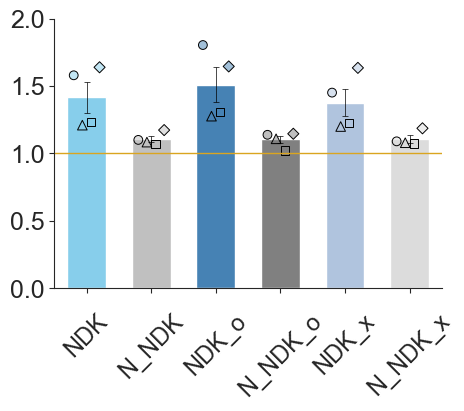

In [13]:
# Visualization: Bar plot
summary_table = plot_df.groupby(['SeriesLabel', 'Date'])['Normalized_Fl_Int-Out'].mean().unstack().reindex(series_list)
d = summary_table
series = d.index
dates = d.columns
raws = np.array(d[dates])
aves = np.average(raws,axis = 1)
ses = np.std(raws, ddof=1, axis=1)/sqrt(len(raws[0]))

cs = [palette[s] for s in series]
facecolors = [mcolors.to_rgba(c, alpha=0.5) for c in cs]
x_position = np.arange(len(series))
error_bar_set = dict(lw = 0.5, capthick = 0.5, capsize = 2)
width = 0.6

fig, ax = plt.subplots(1, 1, figsize=(5,3.5))
ax.bar(x_position, aves, width=width, yerr=ses, error_kw=error_bar_set, color = cs)
ax.set_xticks(x_position), ax.set_xticklabels(series)
plt.xticks(rotation=45)

ms = ['o','^','s','D','v']
ss = np.array([40,48,36,32,48])
L = 12/len(raws[0])
xs = np.linspace(-width/L, width/L, len(dates))

for i in range(len(dates)):
    raw = raws[:,i]
    x = x_position + xs[i]
    ax.scatter(x, raw, color=cs, marker=ms[i], s=ss[i], facecolor=facecolors, edgecolor='k', linewidth=0.7)

ax.plot([-0.5,x_position[-1]+0.5],[1,1], c='goldenrod', linewidth=1, linestyle='-')

ax.tick_params(axis ='x',labelsize =17), ax.tick_params(axis ='y',labelsize =18)
ax.tick_params(axis='x', pad=12)
ax.set_xlim(-0.5, x_position[-1]+0.5)
arrange_axis(ax)

if Type == 'Rep_comm':
    ax.set_ylim(0,2)
elif (Type == 'NTP_comm') & (Droplet_Ser == 'NDK'):
    ax.set_ylim(0,2)
elif (Type == 'NTP_comm') & (Droplet_Ser == 'Rep'):
    ax.set_ylim(0,8) #(0,4)
elif (Type == 'NTP_syn_Rep_comm') & (Droplet_Ser == 'NDK'):
    ax.set_ylim(0,2)
elif (Type == 'NTP_syn_Rep_comm') & (Droplet_Ser == 'Rep'):
    ax.set_ylim(0,3.5)

# Calculate p-values using paired t-tests across experimental dates.
for i in range(3):
    t_stat, p_value = stats.ttest_rel(raws[i*2,:], raws[i*2+1,:])
    print(series[i*2]+' & '+series[i*2+1]+': p=', p_value)